Title

# Week 2 Summary: Multimodal Model Development (Baseline)

**Author:** Huzaira Sultan
**Mentor:** Mateen Yaqoob
**Period:** Day 1-5

This notebook consolidates baseline model development, evaluation, and 
experiment tracking completed during Week 2.

Load Key Results

In [1]:
import pandas as pd

baseline_metrics = pd.read_csv("blip_baseline_evaluation_report.csv")
experiment_comparison = pd.read_csv("experiment_comparison.csv")

print("Zero-shot baseline metrics:")
print(baseline_metrics)
print("\nExperiment comparison:")
print(experiment_comparison)

Zero-shot baseline metrics:
    Metric  Average Score
0     BLEU         0.1968
1  ROUGE-1         0.5569
2  ROUGE-2         0.3138
3  ROUGE-L         0.5383
4   METEOR         0.3950

Experiment comparison:
                run_name  train_size  learning_rate  epochs  num_beams  \
0      exp1_lr5e5_greedy          15        0.00005       1          1   
1      exp2_lr1e4_greedy          15        0.00010       1          1   
2  exp3_lr5e5_beamsearch          15        0.00005       1          3   

   avg_train_loss  avg_val_bleu  
0        8.313227      0.265757  
1        7.249127      0.140023  
2        8.423088      0.283858  


Zero-Shot Baseline Results

## Day 1-2: Zero-Shot BLIP Baseline

Model used: `Salesforce/blip-image-captioning-base` (Hugging Face, pretrained)

Evaluated on 200 Flickr8k validation images with no fine-tuning:

- BLEU: 0.1968
- ROUGE-1: 0.5569
- ROUGE-2: 0.3138
- ROUGE-L: 0.5383
- METEOR: 0.395

Sample Grid Visualization

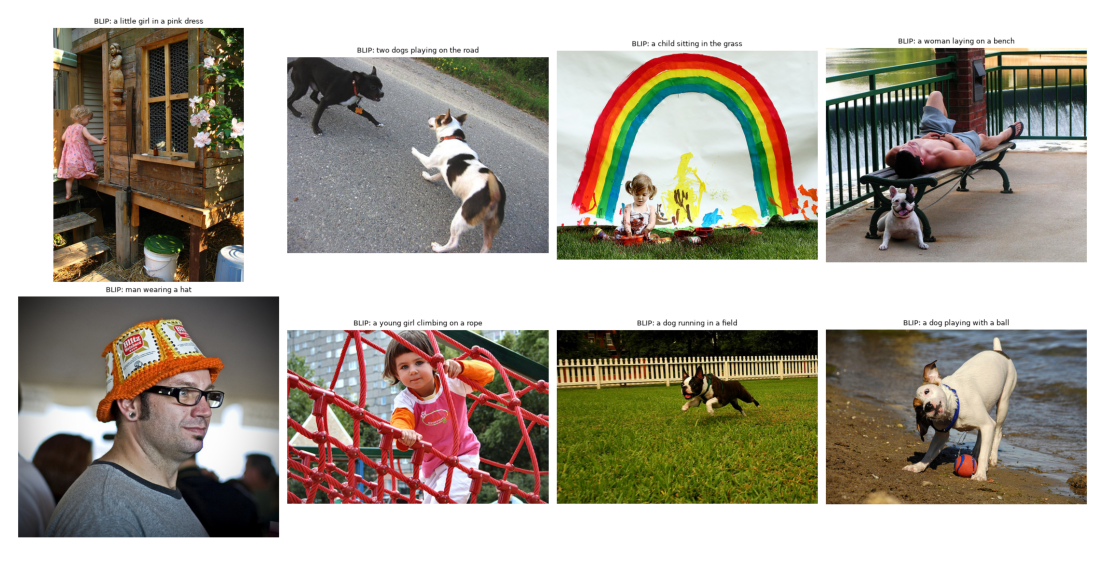

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("blip_zeroshot_samples.png")
plt.figure(figsize=(14,8))
plt.imshow(img)
plt.axis('off')
plt.show()

In [5]:
experiment_comparison

,run_name,train_size,learning_rate,epochs,num_beams,avg_train_loss,avg_val_bleu
0,exp1_lr5e5_greedy,15,0.00005,1,1,8.313227,0.265757
1,exp2_lr1e4_greedy,15,0.00010,1,1,7.249127,0.140023
2,exp3_lr5e5_beamsearch,15,0.00005,1,3,8.423088,0.283858


Chosen Baseline Configuration

## Day 3-4: Fine-Tuning Experiments & Final Baseline Choice

Three configurations were compared (learning rate and decoding strategy):

| Run | Learning Rate | Decoding | Train Loss | Val BLEU |
|---|---|---|---|---|
| exp1_lr5e5_greedy | 5e-05 | Greedy | 8.313 | 0.266 |
| exp2_lr1e4_greedy | 0.0001 | Greedy | 7.249 | 0.140 |
| exp3_lr5e5_beamsearch | 5e-05 | Beam Search (3) | 8.423 | 0.284 |

**Chosen baseline going forward: exp3_lr5e5_beamsearch**

This configuration achieved the highest validation BLEU score (0.284), 
outperforming both greedy-decoding runs. Beam search's ability to 
explore multiple candidate sequences before selecting the final caption 
proved more valuable than a higher learning rate, which instead led to 
lower BLEU despite a lower training loss (suggesting mild overfitting 
on the small 15-image training subset).

All experiment runs were tracked in MLflow under the 
`flickr8k-image-captioning` experiment, allowing full comparison of 
parameters and metrics across runs.

Sample Captions From Chosen Baseline

In [9]:
results_df = pd.read_csv("blip_baseline_full_results.csv")
results_df[['image', 'generated_caption']].head(10)

,image,generated_caption
0,1000268201_693b08cb0e.jpg,a little girl in a pink dress
1,1001773457_577c3a7d70.jpg,two dogs playing on the road
2,1002674143_1b742ab4b8.jpg,a child sitting in the grass
3,1003163366_44323f5815.jpg,a woman laying on a bench
4,1007129816_e794419615.jpg,man wearing a hat
5,1007320043_627395c3d8.jpg,a young girl climbing on a rope
6,1009434119_febe49276a.jpg,a dog running in a field
7,1012212859_01547e3f17.jpg,a dog playing with a ball
8,1015118661_980735411b.jpg,a young boy is walking down the street
9,1015584366_dfcec3c85a.jpg,a dog is sitting on a log in the grass
